# Imports

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
from sklearn.manifold import TSNE

# Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ROOTDIR_DATA = "/content/drive/MyDrive/Polito/ML_in_Applications/data"

In [5]:
issue = np.load(f"{ROOTDIR_DATA}/anomalyDetection_Issue.npy")
labels = np.load(f"{ROOTDIR_DATA}/anomalyDetection_Labels.npy")
normal = np.load(f"{ROOTDIR_DATA}/anomalyDetection_Normal.npy")

In [142]:
print(normal.shape)
print(issue.shape)
print(labels.shape)

(1000, 85)
(400, 85)
(400,)


In [45]:
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal)
issue_scaled = scaler.transform(issue)

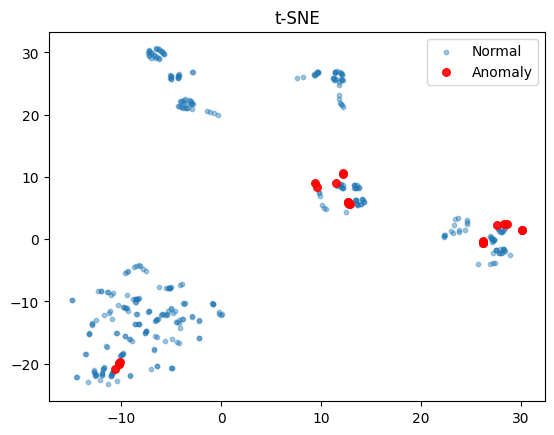

In [127]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
issue_2d = tsne.fit_transform(issue_scaled)

plt.scatter(issue_2d[labels==0, 0], issue_2d[labels==0, 1], alpha=0.4, label="Normal", s=10)
plt.scatter(issue_2d[labels==1, 0], issue_2d[labels==1, 1], alpha=0.9, label="Anomaly", s=30, color="red")
plt.legend(); plt.title("t-SNE")
plt.show()


# Model

In [85]:
class Encoder(tf.keras.Model):
    # Set layers.
    def __init__(self, latent_dim):
        if not isinstance(latent_dim, int):
            raise ValueError("latent_dim must be an integer.")

        super(Encoder, self).__init__()   

        self.fc1 = tf.keras.layers.Dense(64, activation="relu")
        self.bn = tf.keras.layers.BatchNormalization()
        self.fc2 = tf.keras.layers.Dense(32, activation="relu")
        self.out = tf.keras.layers.Dense(latent_dim)

    # Set forward pass.
    def call(self, x):
        x = self.fc1(x)
        x = self.bn(x)
        x = self.fc2(x)
        x = self.out(x)
        return x
    
class Decoder(tf.keras.Model):
    # Set layers.
    def __init__(self):
        
        super(Decoder, self).__init__()  
        self.fc1 = tf.keras.layers.Dense(32, activation="relu")
        self.fc2 = tf.keras.layers.Dense(64, activation="relu")
        self.out = tf.keras.layers.Dense(85)

    # Set forward pass.
    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.out(x)
        return x
    
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder()

    def call(self, x):
        latent = self.encoder(x)
        return self.decoder(latent)


# Training and Inference

In [108]:
model = Autoencoder(latent_dim=6)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=tf.keras.losses.MeanSquaredError())
history = model.fit(normal_scaled, normal_scaled, epochs=100, batch_size=32)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8933
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6735
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5168
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4374
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3841
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3484
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3238
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3030
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2839
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2700
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2592
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2536
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2447
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2383
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2327
Epoc

In [148]:
pred = model(issue_scaled)

In [149]:
# Per-sample MSE: shape (400,) — one score per sample
reconstruction_error = np.mean((issue_scaled - pred.numpy()) ** 2, axis=1)

# Then threshold to classify anomalies
threshold = np.percentile(reconstruction_error, 80)  # tune this
anomaly_mask = reconstruction_error > threshold

# Results

In [153]:
print("Anomalies detected:", np.sum(anomaly_mask))

Anomalies detected: 80


Accuracy: 0.8225
Specificity: 0.8320
Precision: 0.2125


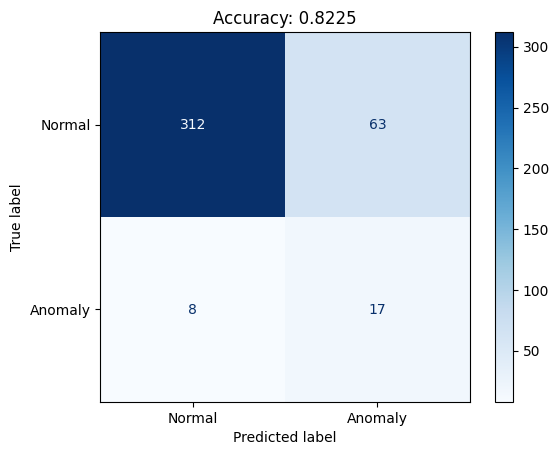

In [154]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

acc = np.mean(anomaly_mask == labels)
specificity = np.sum((anomaly_mask == 0) & (labels == 0)) / np.sum(labels == 0)
precision = np.sum((anomaly_mask==1) & (labels==1)) / np.sum(anomaly_mask==1)

print(f"Accuracy: {acc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

cm = confusion_matrix(labels, anomaly_mask)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_title(f"Accuracy: {acc:.4f}")
plt.show()

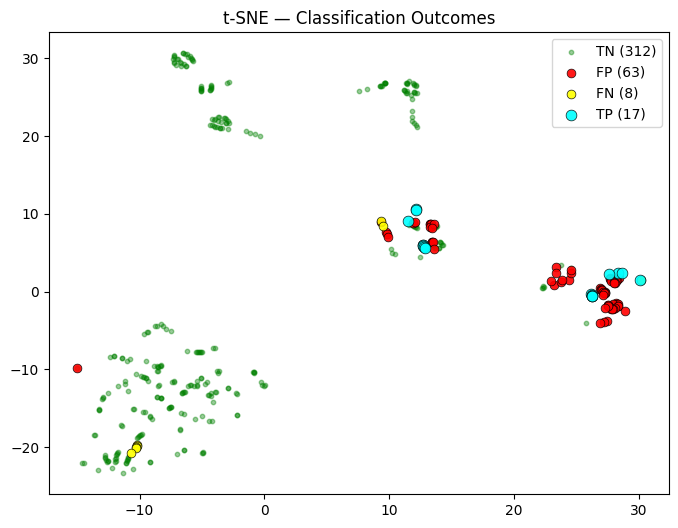

In [ ]:
tsne = TSNE(n_components=2, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

issue_2d = tsne.fit_transform(issue_scaled)


tn = (labels == 0) & (anomaly_mask == 0)
fp = (labels == 0) & (anomaly_mask == 1)
fn = (labels == 1) & (anomaly_mask == 0)
tp = (labels == 1) & (anomaly_mask == 1)

plt.figure(figsize=(8, 6))
plt.scatter(issue_2d[tn, 0], issue_2d[tn, 1], color="green",  alpha=0.4, s=10,  label=f"TN ({tn.sum()})")
plt.scatter(issue_2d[fp, 0], issue_2d[fp, 1], color="red",    alpha=0.9, s=40,  label=f"FP ({fp.sum()})", edgecolors="black", linewidths=0.5)
plt.scatter(issue_2d[fn, 0], issue_2d[fn, 1], color="yellow", alpha=0.9, s=40,  label=f"FN ({fn.sum()})", edgecolors="black", linewidths=0.5)
plt.scatter(issue_2d[tp, 0], issue_2d[tp, 1], color="cyan",   alpha=0.9, s=60,  label=f"TP ({tp.sum()})", edgecolors="black", linewidths=0.5)
plt.legend(); plt.title("t-SNE — Classification Outcomes")
plt.show()


**Coments:** 
- Using 6 dimensions for the latent space was found to be the best result. 
- It is possible to tune the anomaly threshold parameter to the application, depending on business decision (costs for missclassification). The current solution uses 80% percentile, so to capture most anomalies (also leading to many FP)
- In general, the accuracy is usually high (good in finding normal samples), but the precision is poor (classifiying anomalies is hard)
- From the t-SNE plot it is visible that predictions for anormalies focus on two clusters where most anomalies actually are, but miss to identify the anomalies that are generally located closer to normal data 